import libraries

In [2]:
%matplotlib inline

import h5py
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

imports data

In [4]:
# Open file
filepath = "../../Mock_worms/chemotaxis_mock_23_1_23_09_20240123_150906\metadata_featuresN_oneworm.hdf5"

with h5py.File(filepath, 'r') as f:
    # List all datasets
    print("Datasets:", list(f.keys()))
    
    # Load trajectories data as DataFrame
    traj_data = pd.DataFrame(f['trajectories_data'][:])
    
    # Load timeseries features (if present)
    if 'timeseries_data' in f:
        timeseries = pd.DataFrame(f['timeseries_data'][:])
    
    # Load odor patch coordinates
    if 'food_cnt_coord' in f:
        odor_patch = f['food_cnt_coord'][:]
        print(f"Odor patch defined by {len(odor_patch)} boundary points")
    
    # Load skeleton coordinates
    coords = f['coordinates']['skeletons'][:] # Shape: (n_frames, n_segments, 2)

Datasets: ['base_coordinates', 'base_x', 'base_y', 'coordinates', 'food_cnt_coord', 'neck_coordinates', 'neck_x', 'neck_y', 'timeseries_data', 'trajectories_data']
Odor patch defined by 1000 boundary points


take out eigenworms and motion mode

In [7]:
# create a dictionary of eigenworm arrays
# the array called eigenworm1 will be an array of eigen_projection_1, etc
eigenworm_dict = {}
for x in range(1, 7): 
    eigenworm_dict["eigenworm{0}".format(x)] = np.array(timeseries['eigen_projection_{0}'.format(x)])

eigenworm1 = eigenworm_dict['eigenworm1']
eigenworm2 = eigenworm_dict['eigenworm2']
eigenworm3 = eigenworm_dict['eigenworm3']

motion = np.array(timeseries['motion_mode'])

plotting eigenworms (2D)

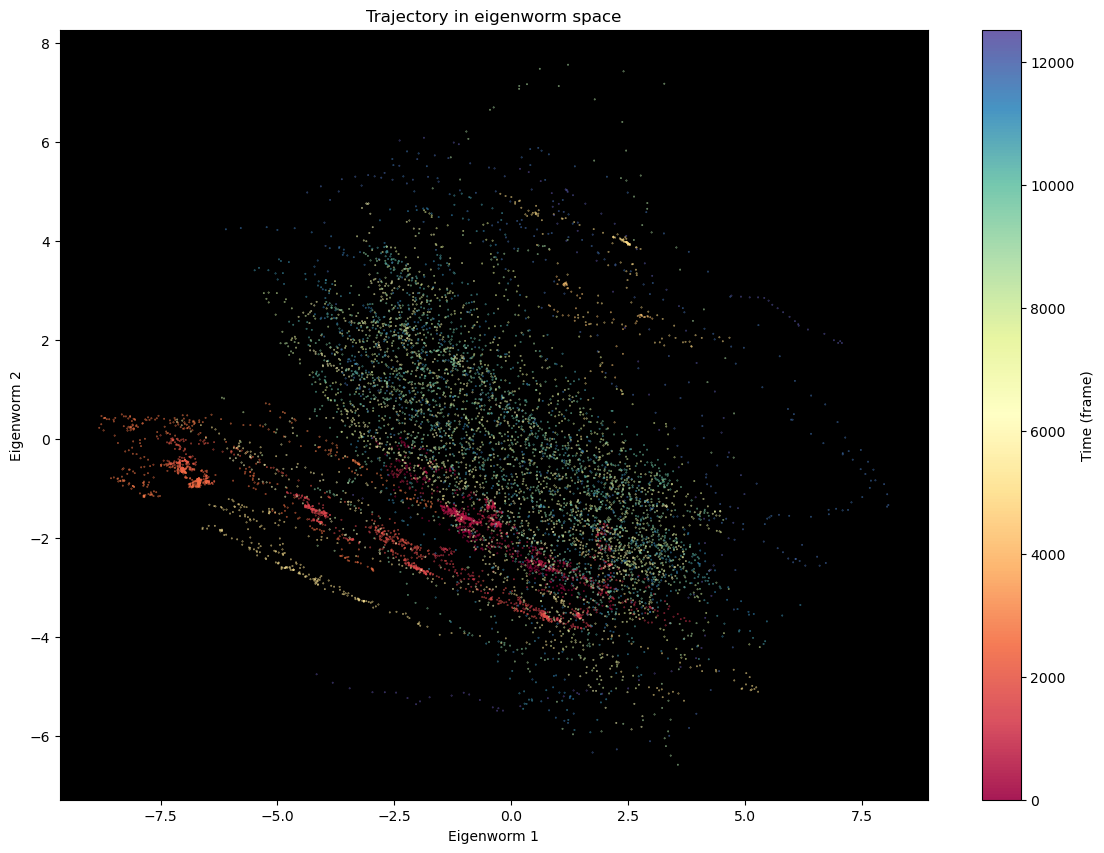

In [ ]:
# trajectory_alpha = np.linspace(0, 1, len(eigenworm1))

fig2d, ax2d = plt.subplots(figsize = (14, 10))

ax2d.set_facecolor('black')


time = np.arange(len(timeseries))

eigenworm1VS2 = plt.scatter(eigenworm1, eigenworm2, c = time, cmap = 'Spectral', s = 0.1, alpha = 1)
plt.xlabel("Eigenworm 1")
plt.ylabel("Eigenworm 2")
plt.title("Trajectory in eigenworm space")

plt.colorbar(eigenworm1VS2, label = "Time (frame)")

Generation of a video that shows the system's evolution from frame 1 to frame 500

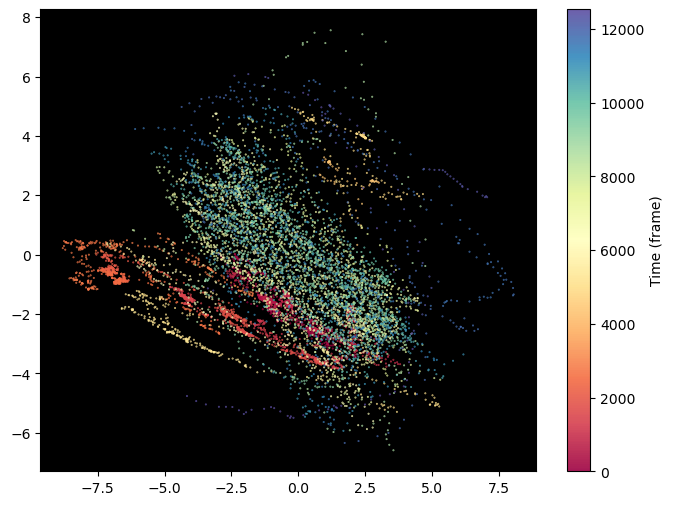

In [ ]:
# %matplotlib notebook
%matplotlib inline

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize = (8, 6))

ax.set_facecolor('black')
eigenworm1VS2 = plt.scatter(eigenworm1, eigenworm2, c = time, cmap = 'Spectral', s = 0.2, alpha = 0.9)
plt.colorbar(eigenworm1VS2, label = "Time (frame)")


start_frame = 4000
end_frame = 4500
frame_step = 1

x_sub = eigenworm1[start_frame:end_frame:frame_step]
y_sub = eigenworm2[start_frame:end_frame:frame_step]


point, = ax.plot([], [], 'wo', markersize = 4, label = "Current position")


def update(frame):
    point.set_data([x_sub[frame]], [y_sub[frame]])
    return point, 

anim = FuncAnimation(fig, update, frames = 500, interval = 50, blit = False, repeat = False)
HTML(anim.to_html5_video())

Trajectory of system in space of the first three eigenprojections (3D)

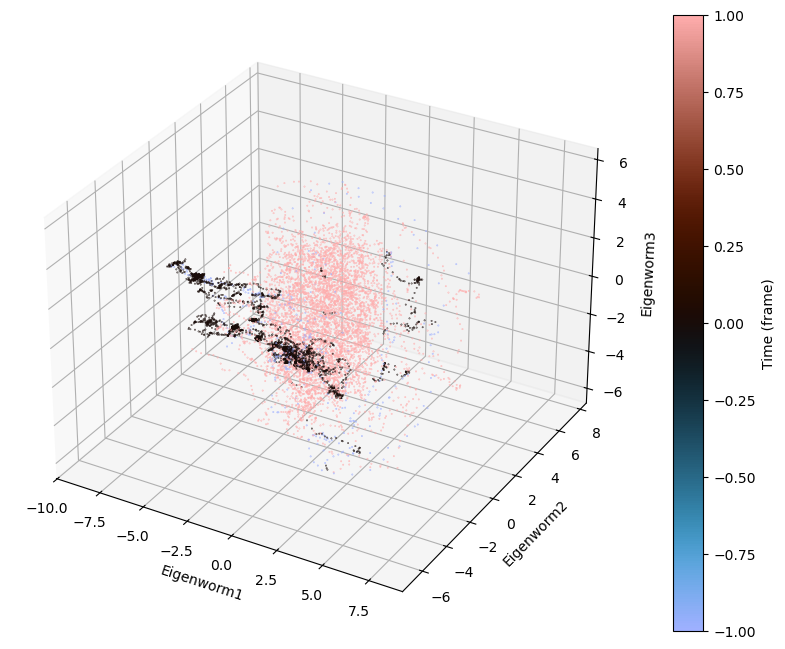

In [15]:
from mpl_toolkits import mplot3d

fig3D = plt.figure(figsize = (12, 8))
ax3D = plt.axes(projection = '3d')

eigenworm1VS2VS3 = ax3D.scatter3D(eigenworm1, eigenworm2, eigenworm3, c = motion, cmap = 'berlin', s = 0.1, alpha = 1)
plt.xlabel("Eigenworm1")
plt.ylabel("Eigenworm2")
ax3D.set_zlabel("Eigenworm3")

plt.colorbar(eigenworm1VS2VS3, label = "Time (frame)")

plt.show()

unpackaging d_eigen_projections into arrays

In [16]:
# create a dictionary of d_eigenworm arrays
# the array called d_eigenworm1 will be an array of d_eigen_projection_1, etc
d_eigenworm_dict = {}
for x in range(1, 7): 
    d_eigenworm_dict["d_eigenworm{0}".format(x)] = np.array(timeseries['d_eigen_projection_{0}'.format(x)])


d_eigenworm1 = np.array(timeseries['d_eigen_projection_1'])
d_eigenworm2 = np.array(timeseries['d_eigen_projection_2'])
d_eigenworm3 = np.array(timeseries['d_eigen_projection_3'])


a view of the time derivative of eigenworm 1

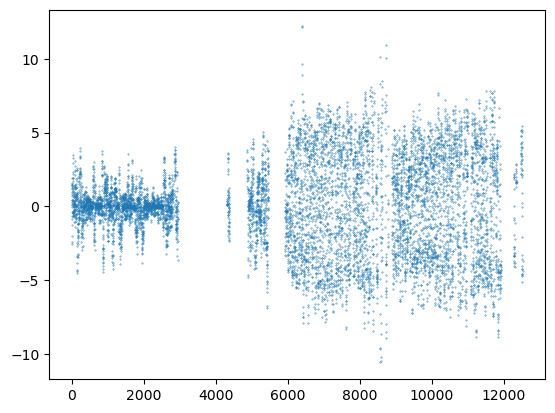

In [170]:
plt.scatter(time, d_eigenworm1, s = 0.1, alpha = 1)

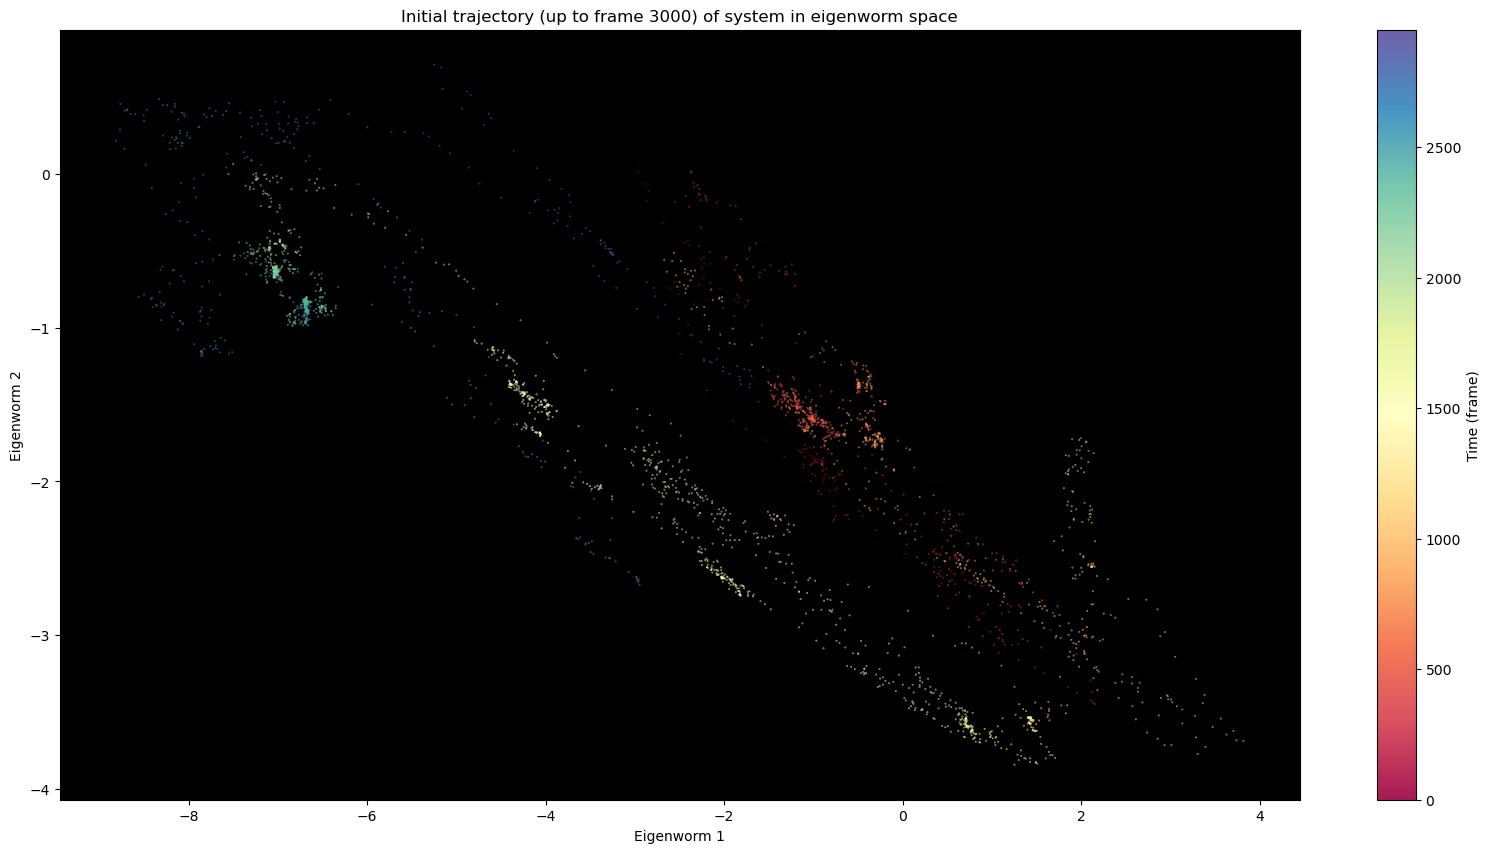

In [40]:
fig2d, ax2d = plt.subplots(figsize = (20, 10))
ax2d.set_facecolor('black')

time = np.arange(len(timeseries))

eigenworm1VS2 = plt.scatter(eigenworm1[0:2999], eigenworm2[0:2999], c = time[0:2999], cmap = 'Spectral', s = 0.1, alpha = 0.9)
# eigenworm1VS2 = plt.scatter(eigenworm1, eigenworm2, c = time, cmap = 'Spectral', s = 0.1, alpha = 0.9)

plt.title("Initial trajectory (up to frame 3000) of system in eigenworm space")

plt.xlabel("Eigenworm 1")
plt.ylabel("Eigenworm 2")
plt.colorbar(eigenworm1VS2, label = "Time (frame)")

Trajectories in eigenworm space color-coded by motion mode

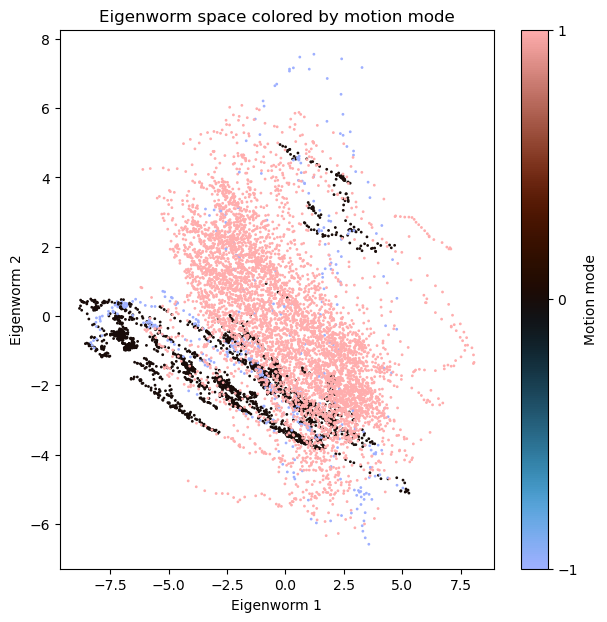

In [197]:
fig, ax = plt.subplots(figsize=(7,7))

# ax.set_facecolor('black')

sc = plt.scatter(eigenworm1, eigenworm2, c=motion, cmap='berlin', s=1, alpha=1)
plt.colorbar(sc, ticks=[-1,0,1], label='Motion mode')
plt.xlabel('Eigenworm 1')
plt.ylabel('Eigenworm 2')
plt.title('Eigenworm space colored by motion mode')
plt.show()

Points in the eigenworm space during worm reversing (motion mode = -1) and pausing (motion mode = 0)

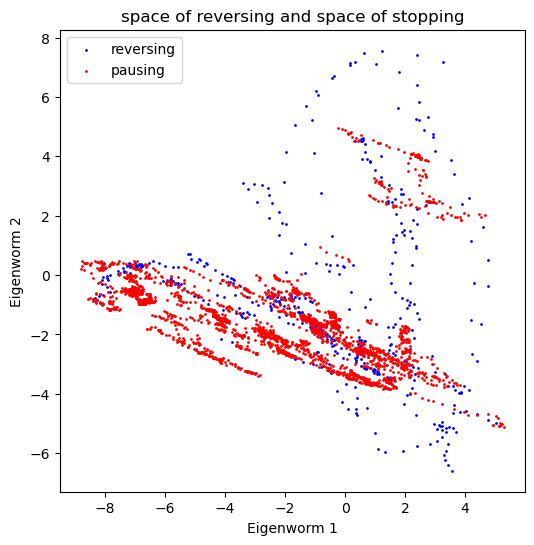

In [19]:
fig, ax = plt.subplots(figsize=(6,6))

reverse_worm1 = []
reverse_worm2 = []

for i in range(len(motion)):
    if motion[i] == -1:
        reverse_worm1.append(eigenworm1[i])
        reverse_worm2.append(eigenworm2[i])



stop_worm1 = []
stop_worm2 = []

for i in range(len(motion)):
    if motion[i] == 0:
        stop_worm1.append(eigenworm1[i])
        stop_worm2.append(eigenworm2[i])


sc = plt.scatter(reverse_worm1, reverse_worm2, color = 'b',  s=1, alpha=1)
sc = plt.scatter(stop_worm1, stop_worm2, color = 'r',  s=1, alpha=1)
plt.legend(["reversing", "pausing"])
plt.xlabel('Eigenworm 1')
plt.ylabel('Eigenworm 2')
plt.title('space of reversing and space of stopping')
plt.show()